=== 📊 STEP 1: INITIAL DATA SNIPPET ===
     Item_ID Food_Category    Item_Brand Packaging_Type
0  FOOD-8270        Bakery       Fortune         Packet
1  FOOD-1860    Vegetables       Fortune         Packet
2  FOOD-6390         Dairy  Catch_Spices         Packet
3  FOOD-6191        Bakery     Britannia            Box
4  FOOD-6734    Vegetables          Amul         Packet

💾 'grocery_brand_report.csv' saved successfully.



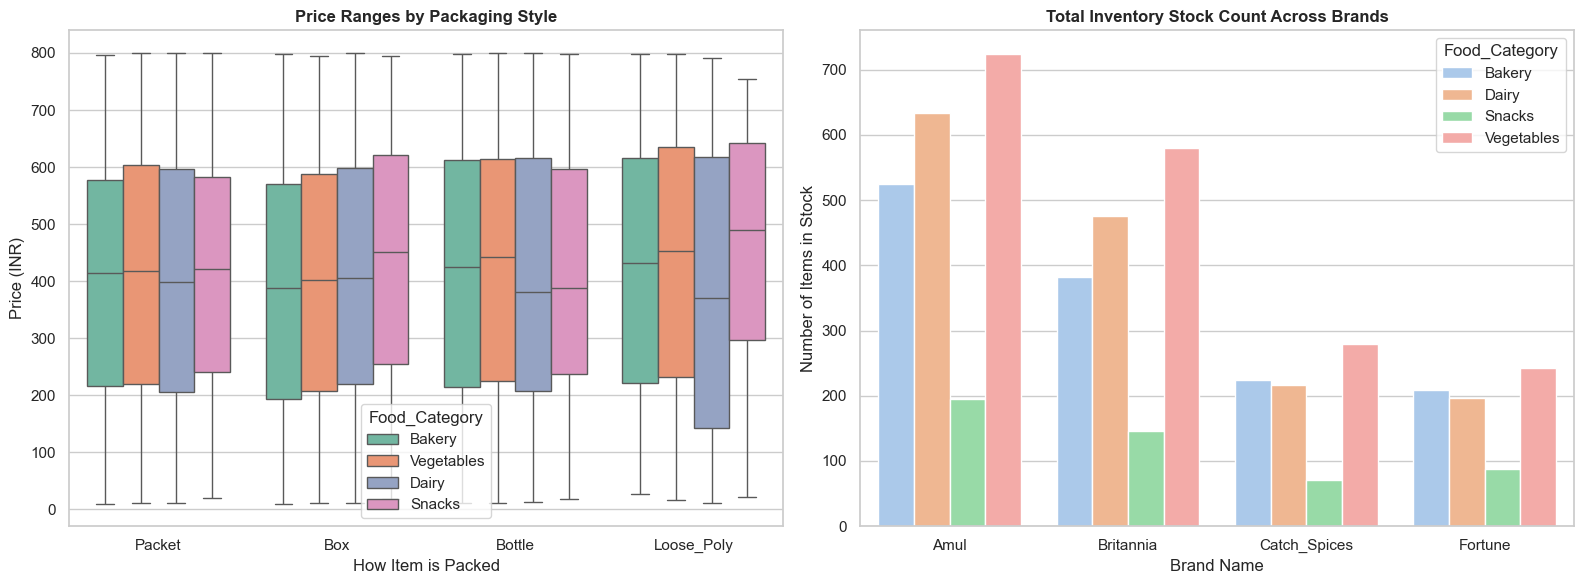

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Read our simplified grocery file
df = pd.read_csv('easy_grocery_inventory.csv')
print("=== 📊 STEP 1: INITIAL DATA SNIPPET ===")
print(df[['Item_ID', 'Food_Category', 'Item_Brand', 'Packaging_Type']].head(5))
print("=========================================\n")

# ===================================================================
# 1. CLEARING OUT IMPOSSIBLE WEIGHT GLITCHES
# =================================================================

# Drop broken weights (less then og or glitched 99,999g) and items with 0 price

valid_food_mask = (df['Weight_Grams'] >0 & (df['Weight_Grams'] < 10000) & (df['Item_Price_INR'] > 0))
df = df[valid_food_mask]

# ==================================================================
# 2. SMART FILLING: ESTIMATING CALORIES BY FOOD TYPE
# ==================================================================
# Contextual filling: Use the median value of that specific food category to fill its blanks
df['Estimated_Calories'] = df['Estimated_Calories'].fillna(
    df.groupby('Food_Category')['Estimated_Calories'].transform('median')
)

# ==================================================================
# 3. VALUE FOR MONEY METRIC & BRAND AGGREGATION
# ==================================================================
# Calculate cost per single gram
df['Cost_Per_Gram_INR'] = df['Item_Price_INR'] / df['Weight_Grams']

# Create a clear Brand Performance Report
brand_report = df.groupby(['Item_Brand', 'Food_Category']).agg(
    Total_Products_Stocked = ('Item_ID','count'),
    Average_Price_INR= ('Item_Price_INR', 'mean'),
    Average_Weight_Grams = ('Weight_Grams','mean'),
    Total_Calories_Stock = ('Estimated_Calories','sum')
).reset_index()

brand_report.to_csv('grocery_brand_report.csv', index=False)
print("💾 'grocery_brand_report.csv' saved successfully.\n")

# ==================================================================
# 4. SIMPLE REAL-WORLD PLOTS
# ==================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Price distribution across different Packaging Types
sns.boxplot(
    x='Packaging_Type',
    y='Item_Price_INR',
    hue='Food_Category',
    data=df,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Price Ranges by Packaging Style', fontweight='bold', fontsize=12)
axes[0].set_xlabel('How Item is Packed')
axes[0].set_ylabel('Price (INR)')

# Chart 2: Total Items Stocked per Brand
sns.barplot(
    x='Item_Brand',
    y='Total_Products_Stocked',
    hue='Food_Category',
    data=brand_report,
    palette='pastel',
    ax=axes[1]
)
axes[1].set_title('Total Inventory Stock Count Across Brands', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Brand Name')
axes[1].set_ylabel('Number of Items in Stock')

plt.tight_layout()
plt.show()